#Project: Covid-19_Prediction_Model_Nueral_Nets
 Author : Poorvi Rajendra Raut

##Importing necessary python libraries

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the CSV files

In [84]:
final_train=pd.read_csv('/content/drive/MyDrive/Covid19_Prediction/final_train.csv')
final_test=pd.read_csv('/content/drive/MyDrive/Covid19_Prediction/final_test.csv')
final_submission=pd.read_csv('/content/drive/MyDrive/Covid19_Prediction/final_gender_submission.csv')

In [85]:
#Display basic info
final_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PatientID         891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   SeverityLevel     891 non-null    int64  
 3   FullName          891 non-null    object 
 4   Gender            891 non-null    object 
 5   Age               714 non-null    float64
 6   CloseContacts     891 non-null    int64  
 7   FamilyInfected    891 non-null    int64  
 8   CaseID            891 non-null    object 
 9   TreatmentCost     891 non-null    float64
 10  IsolationWard     204 non-null    object 
 11  HospitalLocation  889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [86]:
final_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PatientID         418 non-null    int64  
 1   SeverityLevel     418 non-null    int64  
 2   FullName          418 non-null    object 
 3   Gender            418 non-null    object 
 4   Age               332 non-null    float64
 5   CloseContacts     418 non-null    int64  
 6   FamilyInfected    418 non-null    int64  
 7   CaseID            418 non-null    object 
 8   TreatmentCost     417 non-null    float64
 9   IsolationWard     91 non-null     object 
 10  HospitalLocation  418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [87]:
final_train.head()


,PatientID,Survived,SeverityLevel,FullName,Gender,Age,CloseContacts,FamilyInfected,CaseID,TreatmentCost,IsolationWard,HospitalLocation
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [88]:
final_test.head()

,PatientID,SeverityLevel,FullName,Gender,Age,CloseContacts,FamilyInfected,CaseID,TreatmentCost,IsolationWard,HospitalLocation
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [89]:
final_submission.shape


(418, 2)

##Data Cleaning and Pre-processing

In [90]:
final_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PatientID         891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   SeverityLevel     891 non-null    int64  
 3   FullName          891 non-null    object 
 4   Gender            891 non-null    object 
 5   Age               714 non-null    float64
 6   CloseContacts     891 non-null    int64  
 7   FamilyInfected    891 non-null    int64  
 8   CaseID            891 non-null    object 
 9   TreatmentCost     891 non-null    float64
 10  IsolationWard     204 non-null    object 
 11  HospitalLocation  889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [91]:
final_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PatientID         418 non-null    int64  
 1   SeverityLevel     418 non-null    int64  
 2   FullName          418 non-null    object 
 3   Gender            418 non-null    object 
 4   Age               332 non-null    float64
 5   CloseContacts     418 non-null    int64  
 6   FamilyInfected    418 non-null    int64  
 7   CaseID            418 non-null    object 
 8   TreatmentCost     417 non-null    float64
 9   IsolationWard     91 non-null     object 
 10  HospitalLocation  418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


### 1. Handling Missing Values

In [92]:
# Checking for missing values
print(final_train.isnull().values.any())
print(final_test.isnull().values.any())

True
True


In [93]:
#Filling missing values
#All numerical value with mean
final_train.fillna(final_train.mean(numeric_only=True), inplace=True)
final_test.fillna(final_test.mean(numeric_only=True), inplace=True)

#All categorical values with mode
final_train.fillna(final_train.mode().iloc[0], inplace=True)
final_test.fillna(final_test.mode().iloc[0], inplace=True)

In [94]:
#Converting categorical variables to numeric values (manually using pandas)
#1. Convert Gender (Male/Female → 0/1)
final_train['Gender'] = final_train['Gender'].map({'male': 0, 'female': 1})
final_test['Gender'] = final_test['Gender'].map({'male': 0, 'female': 1})

#Convert HospitalLocation (Categorical → Numeric)
print(final_train['HospitalLocation'].unique())
# Map values manually
hospital_mapping = {'C': 0, 'Q': 1, 'S': 2}  # Assign numeric values
final_train['HospitalLocation'] = final_train['HospitalLocation'].map(hospital_mapping)
final_test['HospitalLocation'] = final_test['HospitalLocation'].map(hospital_mapping)

## One-hot encoding for IsolationWard (multi-class encoding) #study that
#final_train = pd.get_dummies(final_train, columns=['IsolationWard'], drop_first=True)
#final_test = pd.get_dummies(final_test, columns=['IsolationWard'], drop_first=True)

['S' 'C' 'Q']


In [95]:
# Check dataset after transformation
print(final_train.head())
print(final_test.head())

   PatientID  Survived  SeverityLevel  \
0          1         0              3   
1          2         1              1   
2          3         1              3   
3          4         1              1   
4          5         0              3   

                                            FullName  Gender   Age  \
0                            Braund, Mr. Owen Harris       0  22.0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...       1  38.0   
2                             Heikkinen, Miss. Laina       1  26.0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)       1  35.0   
4                           Allen, Mr. William Henry       0  35.0   

   CloseContacts  FamilyInfected            CaseID  TreatmentCost  \
0              1               0         A/5 21171         7.2500   
1              1               0          PC 17599        71.2833   
2              0               0  STON/O2. 3101282         7.9250   
3              1               0            113803      

In [96]:
# Checking for missing values
print(final_train.isnull().values.any())
print(final_test.isnull().values.any())

False
False


In [97]:
print(final_train.columns)

Index(['PatientID', 'Survived', 'SeverityLevel', 'FullName', 'Gender', 'Age',
       'CloseContacts', 'FamilyInfected', 'CaseID', 'TreatmentCost',
       'IsolationWard', 'HospitalLocation'],
      dtype='object')


In [98]:
#dropping few unneccecary columns
drop_columns = ['PatientID', 'FullName', 'CaseID', 'IsolationWard']

# Drop from train and test datasets
final_train.drop(columns=drop_columns, inplace=True)
final_test.drop(columns=drop_columns, inplace=True)

# Verify changes
print(final_train.head())
print(final_test.head())

   Survived  SeverityLevel  Gender   Age  CloseContacts  FamilyInfected  \
0         0              3       0  22.0              1               0   
1         1              1       1  38.0              1               0   
2         1              3       1  26.0              0               0   
3         1              1       1  35.0              1               0   
4         0              3       0  35.0              0               0   

   TreatmentCost  HospitalLocation  
0         7.2500                 2  
1        71.2833                 0  
2         7.9250                 2  
3        53.1000                 2  
4         8.0500                 2  
   SeverityLevel  Gender   Age  CloseContacts  FamilyInfected  TreatmentCost  \
0              3       0  34.5              0               0         7.8292   
1              3       1  47.0              1               0         7.0000   
2              2       0  62.0              0               0         9.6875   
3      

### 2.Feature Engineering: Create new features based on existing ones.
Age Group: Categorize age into groups.
High Risk: Identify patients with more CloseContacts and FamilyInfected.

In [99]:
# Create Age Group
final_train['AgeGroup'] = pd.cut(final_train['Age'], bins=[0, 18, 40, 60, 100], labels=[0, 1, 2, 3])
final_test['AgeGroup'] = pd.cut(final_test['Age'], bins=[0, 18, 40, 60, 100], labels=[0, 1, 2, 3])

# Create High Risk Feature
final_train['HighRisk'] = (final_train['CloseContacts'] + final_train['FamilyInfected']) > 2
final_test['HighRisk'] = (final_test['CloseContacts'] + final_test['FamilyInfected']) > 2

# Convert boolean to integer
final_train['HighRisk'] = final_train['HighRisk'].astype(int)
final_test ['HighRisk'] = final_test['HighRisk'].astype(int)

print(final_train.head(5))
#print(final_test.head(5))



   Survived  SeverityLevel  Gender   Age  CloseContacts  FamilyInfected  \
0         0              3       0  22.0              1               0   
1         1              1       1  38.0              1               0   
2         1              3       1  26.0              0               0   
3         1              1       1  35.0              1               0   
4         0              3       0  35.0              0               0   

   TreatmentCost  HospitalLocation AgeGroup  HighRisk  
0         7.2500                 2        1         0  
1        71.2833                 0        1         0  
2         7.9250                 2        1         0  
3        53.1000                 2        1         0  
4         8.0500                 2        1         0  


### 3.Exploratory data Analysis (EDA) :
Now, will explore every features, so we can remove unnecessary data-columns and select only those data-columns which has significance to classify the target variable which is Survived in our case with Binary value 0 and 1 and plot visualizations.

In [100]:
#b.Plot visualizations
# Checking Target/Class variable frequency distribution
print(final_train['Survived'].value_counts())


Survived
0    549
1    342
Name: count, dtype: int64


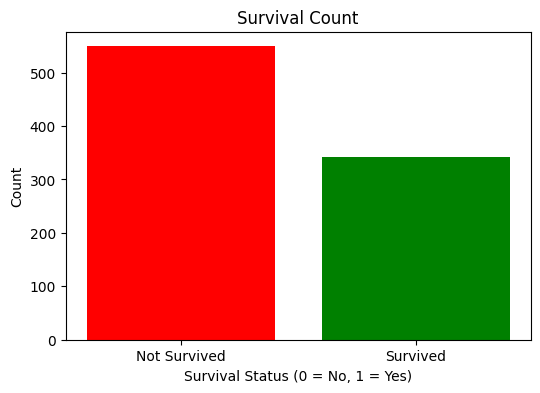

In [101]:
# Count Survived vs. Not Survived
survival_counts = final_train['Survived'].value_counts()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(survival_counts.index, survival_counts.values, color=['red', 'green'])
plt.xlabel("Survival Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Survival Count")
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()

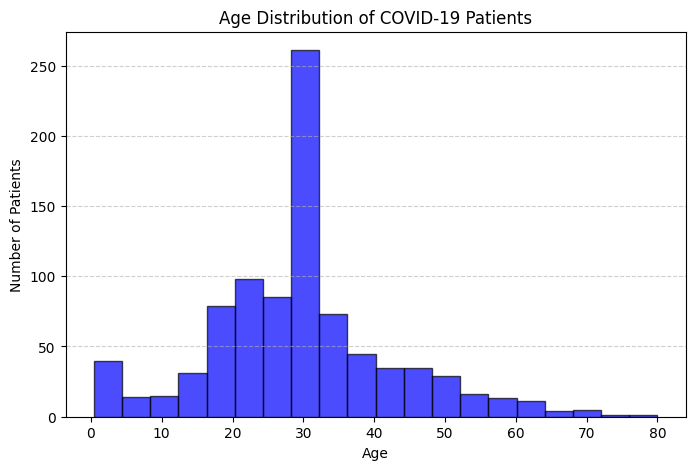

In [102]:
#Plot for age distribution
'''
sns.histplot(final_train['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()
'''
plt.figure(figsize=(8, 5))
plt.hist(final_train['Age'], bins=20, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of COVID-19 Patients")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

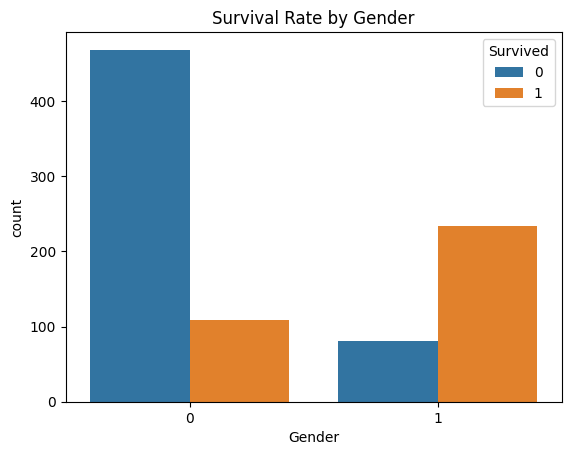

'\nplt.figure(figsize=(8, 5))\nplt.scatter(final_train[\'Gender\'], final_train[\'Survived\'], alpha=0.5, color=\'purple\')\nplt.xlabel("Gender")\nplt.ylabel("Survived count")\nplt.title("Gender vs. Survival rate")\nplt.grid(True)\nplt.show()\n'

In [103]:
# Gender vs Survival Rate

sns.countplot(x='Gender', hue='Survived', data=final_train)
plt.title("Survival Rate by Gender")
plt.show()

'''
plt.figure(figsize=(8, 5))
plt.scatter(final_train['Gender'], final_train['Survived'], alpha=0.5, color='purple')
plt.xlabel("Gender")
plt.ylabel("Survived count")
plt.title("Gender vs. Survival rate")
plt.grid(True)
plt.show()
'''

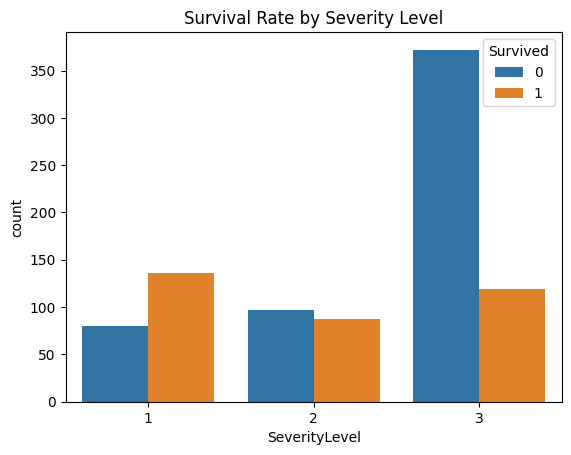

In [104]:
# Plot for Severity Level vs Survival
sns.countplot(x='SeverityLevel', hue='Survived', data=final_train)
plt.title("Survival Rate by Severity Level")
plt.show()

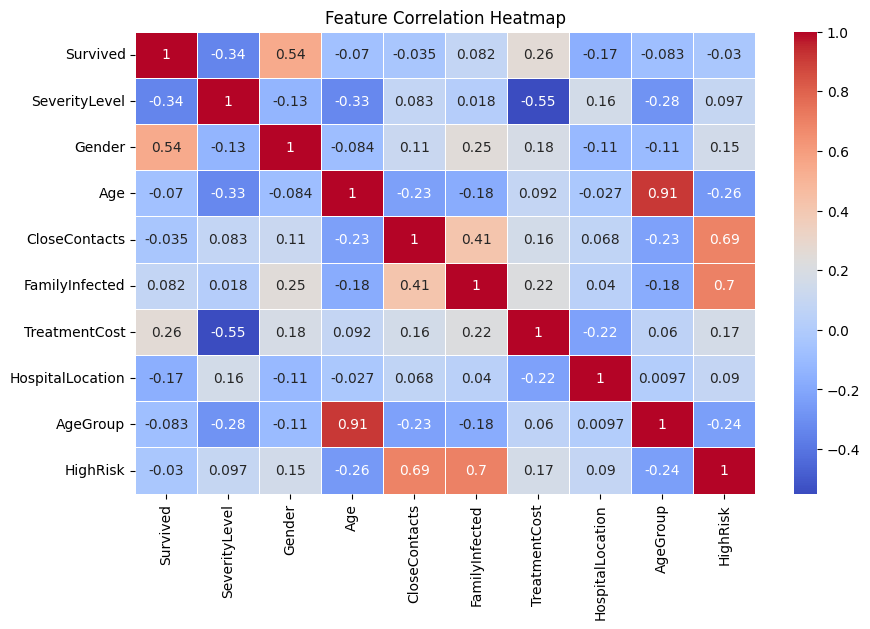

In [105]:
plt.figure(figsize=(10,6))
sns.heatmap(final_train.corr(),annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### Splitting of Dataset Train-test split (70% train, 30% validation)

In [106]:
X = final_train.drop(columns=['Survived']).values
y = final_train['Survived'].values.astype(int)

In [107]:
#Train-test split (70% train, 30% validation)
split_idx = int(0.7 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_test:", np.unique(y_test))


Unique values in y_train: [0 1]
Unique values in y_test: [0 1]


In [108]:
# Display shape of data after preprocessing
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((623, 9), (268, 9), (623,), (268,))

#Two Layer Perceptron (Feed-Forward Neural Net)

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Activation Functions

In [110]:

def linear(H):
    return H


def Sigmoid(H):
    return 1 / (1 + np.exp(-H))


# regression function
def ReLU(H):
    return H * (H > 0)


def softmax(H):
    eH = np.exp(H)
    return eH / eH.sum(axis=1, keepdims=True)


def one_hot_encode(y):
    N = len(y)
    K = len(set(y))
    Y = np.zeros((N, K))
    for i in range(N):
        Y[i, y[i]] = 1
    return Y


def accuracy(y, y_hat):
    return np.mean(y == y_hat)


def cross_entropy(Y, P_hat):
    return -np.sum(Y * np.log(P_hat))

Useful Functions

##Shallow ANN Class

In [111]:
class Shallow_ANN():
    def fit(self, X, y, neurons=6, eta=1e-3, epochs=1e3, show_curve=True):
        epochs = int(epochs)
        N, D = X.shape
        Y = one_hot_encode(y)
        K = Y.shape[1]
        # Initialize Weights and Biases
        self.W = {l: np.random.randn(M[0], M[1]) for l, M in
                 enumerate(zip([D, neurons], [neurons, K]), 1)}
        self.B = {l: np.random.randn(M) for l, M in enumerate([neurons, K], 1)}
        # Define Activations
        self.a = {1: np.tanh, 2: softmax}

        J = np.zeros(epochs)
        # SDG Steps
        for epoch in range(epochs):
            self.__forward__(X)
            J[epoch] = cross_entropy(Y, self.Z[2])
            # output for the Layer 2 Backpropagation.
            self.W[2] -= eta * (1 / N) * self.Z[1].T @ (self.Z[2] - Y)
            self.B[2] -= eta * (1 / N) * (self.Z[2] - Y).sum(axis=0)
            # Weight Update Rules for Layer 1
            self.W[1] -= eta * (1 / N) * X.T @ (
                    (self.Z[2] - Y) @ self.W[2].T * (1 - self.Z[1] ** 2))
            self.B[1] -= eta * (1 / N) * (
                    (self.Z[2] - Y) @ self.W[2].T * (1 - self.Z[1] ** 2)).sum(
                axis=0)
        if show_curve:
            plt.figure()
            plt.plot(J)
            plt.xlabel("epochs")
            plt.ylabel("$\mathcal{J}$")
            plt.title("Training Curve")
        return self.W, self.B

    def __forward__(self, X):
        self.Z = {0: X}
        for l in sorted(self.W.keys()):
            self.Z[l] = self.a[l](self.Z[l - 1] @ self.W[l] + self.B[l])

    def predict(self, X):
        self.__forward__(X)  # Call __forward__ to calculate Z values before prediction
        return self.Z[2].argmax(axis=1)



In [112]:
def main():
    D = X_train.shape[1]  # Set D to the number of features in X_train
    K = len(set(y_train))  # Set K to the number of unique classes in y_train
    #N= int(K*1e3)

    #X0= np.random.randn((N//K),D) + np.array([2,2])
    #X1= np.random.randn((N//K),D) + np.array([0,-2])
    #X2= np.random.randn((N//K),D) + np.array([-2,2])
    #X=np.vstack((X0,X1,X2))

    #y=np.array([0]*(N//K)+ [1]*(N//K)+ [2]*(N//K))

    #plt.figure()
    #plt.scatter(X[:,0],X[:,1], c=y , s= 5)


    my_ann = Shallow_ANN()
    my_ann.fit(X_train, y_train, neurons=3, eta=1e-2, epochs=3e4,
               show_curve=True)
    y_hat = my_ann.predict(X_test)

    print("Accuracy: ", accuracy(y_test, y_hat))
    print(my_ann.W)
    print(my_ann.B)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_hat, s=20, cmap='viridis')  # Increased marker size and added a colormap
    plt.colorbar(label='Predicted Output')  # Added a colorbar to show the mapping of colors to output values
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Shallow ANN: Scatter Plot of Test Data with Predictions')
    plt.grid(True)
    plt.show()

Accuracy:  0.7201492537313433
{1: array([[-0.24458904, -0.7456028 , -1.03360539],
       [ 0.34820883, -0.68768087, -1.09458612],
       [ 0.31735376,  1.44142309, -0.27001826],
       [ 0.90026296,  1.58453578, -0.44565397],
       [-0.12036237,  0.75264963, -1.02946292],
       [ 0.00731396, -0.40780102, -1.45890332],
       [-0.6287236 ,  0.02238768, -0.9166253 ],
       [ 0.66762508,  0.10067679,  0.05267754],
       [ 0.95825752, -0.26709085,  0.99973493]]), 2: array([[ 0.43883312, -1.69472202],
       [ 0.44903817,  0.02519997],
       [-0.57374084, -0.17713903]])}
{1: array([-1.0678747 , -0.54912703, -0.79291074]), 2: array([0.06542135, 2.43255014])}


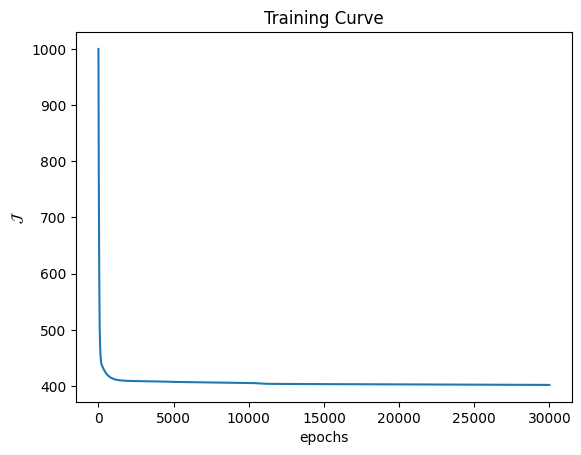

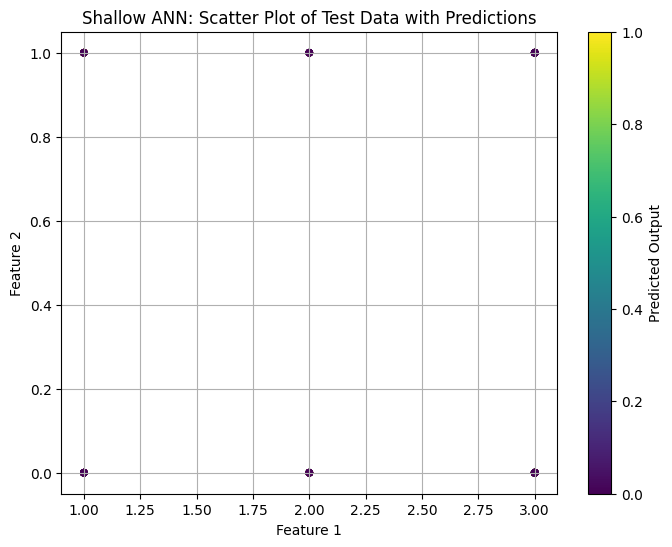

In [113]:
if __name__=="__main__":
  main()

In [114]:
D=2
K=3
neurons=6

In [115]:
W1={l:np.random.randn(M[0],M[1]) for l,M in enumerate(zip([D,neurons],[neurons,K]),1)}

In [116]:
W1

{1: array([[-1.3563569 ,  1.0291898 , -0.54084875,  0.29011373, -0.09275204,
         -0.61741339],
        [ 1.76171358, -0.56954876, -1.49806054, -1.35456359, -0.26938733,
          0.70904726]]),
 2: array([[-0.82638698, -0.63460567, -1.05602612],
        [-1.53470206, -0.73121314,  0.24495025],
        [ 0.39365217,  1.79105911, -1.23100218],
        [ 0.67545366, -0.51993737, -0.12183152],
        [-0.2752978 , -0.03605715, -0.32211697],
        [-0.07464224,  0.50830414, -0.09499824]])}


##Artificial Neural Network with Variable Architecture and Back Propagation

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [118]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000','#00FF00','#0000FF'])
cmap_light = ListedColormap(['#FFBBBB','#BBFFBB','#BBBBFF'])

In [119]:
# Activations

def linear(H):
  return H

def ReLU(H):
  return H*(H>0)

def sigmoid(H):
  return 1/(1+np.exp(-H))

def softmax(H):
  eH=np.exp(H)
  return eH/eH.sum(axis=1, keepdims=True)

#Loss Functions

def cross_entropy(Y, P_hat):
  return -(1/len(Y))*np.sum(Y*np.log(P_hat))

def OLS(Y, Y_hat):
  return (1/(2*len(Y)))*np.sum((Y-Y_hat)**2)

#Misc

def one_hot(y):
  N=len(y)
  K=len(set(y))
  Y = np.zeros((N,K))

  for i in range(N):
    Y[i,y[i]]=1

  return Y

def accuracy(y,y_hat):
  return np.mean(y==y_hat)

def R2(y,y_hat):
  return 1-np.sum((y-y_hat)**2)/np.sum((y - y.mean())**2)

In [120]:
def derivative(Z,a):
  if a==linear:
    return 1
  elif a==sigmoid:
    return Z*(1-Z)
  elif a==np.tanh:
    return 1-Z*Z
  elif a==ReLU:
    return (Z>0).astype(int)

  else:
    ValueError("UnknownActivation")

## ANN Class

In [121]:
class ANN():
  def __init__(self, architecture, activations=None, mode=0):
    self.mode=mode
    self.architecture=architecture
    self.activations = activations
    self.L = len(architecture)+1

  def fit (self, X, y, eta=1e-3, epochs=1e3, show_curve=True):
    epochs = int(epochs)

    if self.mode:
      Y=y
      K=1
    else:
      Y=one_hot(y)
      K=Y.shape[1]

    N, D = X.shape
    # Initialize Weights and Biases
    self.W = {l: np.random.randn(M[0],M[1]) for l, M in enumerate(zip(([D]+self.architecture), (self.architecture +[K])),1)}
    self.B = {l: np.random.randn(M) for l, M in enumerate(self.architecture+[K],1)}


    #Activations
    if self.activations is None:
      self.a= {l: ReLU for l in range(1, self.L)}
    else:
      self.a={l: act for l,act in enumerate(self.activations, 1)}

    #Output Activation Functions
    if self.mode:
      self.a[self.L]=linear
    else:
      self.a[self.L]=softmax

    J = np.zeros(epochs)

    #SGD Progression
    for epoch in range(epochs):
      self.__forward__(X)
      if self.mode:
        J[epoch]=OLS(Y, self.Z[self.L])
      else:
        J[epoch]=cross_entropy(Y, self.Z[self.L])

      dH = (1/N)*(self.Z[self.L]-Y)

      for l in sorted(self.W.keys(), reverse=True):

        dW = self.Z[l-1].T@dH
        dB = dH.sum(axis=0)

        self.W[l] -= eta*dW
        self.B[l] -= eta*dB

        if l>1:
          dZ =dH@self.W[l].T
          dH = dZ*derivative(self.Z[l-1], self.a[l-1])

    if show_curve:
      plt.figure()
      plt.plot(J)
      plt.xlabel("epochs")
      plt.ylabel("$\mathcal{J}$")
      plt.title("Training Curve")

  def __forward__(self,X):
    self.Z={0:X}
    for l in sorted(self.W.keys()):
      self.Z[l] = self.a[l](self.Z[l-1]@self.W[l]+self.B[l])


  def predict(self, X):
    self.__forward__(X)
    if self.mode:
      return self.Z[self.L]
    else:
      return self.Z[self.L].argmax(axis=1)


## Implementation of ANN Classification

In [122]:
def main_class():
    D = X_train.shape[1]
    K = len(set(y_train))
    N = int(K*1e3)

    # Adjust the shape of the added arrays to match the number of features (D)
    X0 = np.random.randn((N//K),D) + np.array([2] * D)  # Repeat 2, D times
    X1 = np.random.randn((N//K),D) + np.array([0] * D)  # Repeat 0, D times
    X2 = np.random.randn((N//K),D) + np.array([-2] * D) # Repeat -2, D times
    X = np.vstack((X0,X1,X2))

    y = np.array([0]*(N//K) + [1]*(N//K) + [2]*(N//K))

    plt.figure()
    plt.scatter(X[:,0],X[:,1], c=y, s=6, alpha=0.6)

    my_ann_classifier=ANN(architecture=[6,4],activations=[np.tanh,ReLU,ReLU])
    my_ann_classifier.fit(X_train,y_train,eta=1e-2,epochs=1e2)
    y_hat=my_ann_classifier.predict(X_test)

    print(my_ann_classifier.W)
    print(my_ann_classifier.B)
    print(f"Training Accuracy:{accuracy(y_test,y_hat):0.4F}")


    x1 = np.linspace(X[:,0].min() - 1, X[:,0].max() + 1, 1000)
    x2 = np.linspace(X[:,1].min() - 1, X[:,1].max() + 1, 1000)

    xx1, xx2 = np.meshgrid(x1, x2)
    num_grid_points = xx1.ravel().shape[0]
    grid_data = np.zeros((num_grid_points, D))
    grid_data[:, 0] = xx1.ravel()
    grid_data[:, 1] = xx2.ravel()

    Z = my_ann_classifier.predict(grid_data).reshape(*xx1.shape)


    plt.figure()
    plt.pcolormesh(xx1, xx2, Z, cmap = cmap_light)
    plt.scatter(X[:,0], X[:,1], c = y, cmap = cmap_bold,alpha=0.2)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_hat, s=20, cmap='viridis')  # Increased marker size and added a colormap
    plt.colorbar(label='Predicted Output')  # Added a colorbar to show the mapping of colors to output values
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Shallow ANN: Scatter Plot of Test Data with Predictions')
    plt.grid(True)
    plt.show()

{1: array([[ 0.11109452, -0.45241077,  1.14845159,  0.55948938,  0.46629035,
         0.79964571],
       [-0.10125972, -0.15467589,  1.34799406, -0.65812472, -0.78678505,
         0.61996979],
       [ 1.25402116,  1.0644534 , -2.48778599,  0.70810031,  0.0157562 ,
        -0.6399196 ],
       [ 0.06802663,  0.82882727,  0.2552836 ,  0.14078699,  0.75835502,
         0.15722563],
       [ 0.37676146, -0.34609166, -1.06793826,  0.63974342,  1.42113242,
        -0.067866  ],
       [ 1.71094752,  1.36867776,  0.67613945, -0.04432336,  0.21929136,
        -1.86476237],
       [ 0.66294016, -0.65831643,  0.22649073, -1.05958279,  0.35445551,
        -2.01974866],
       [-1.37789303,  1.36423183, -0.6871636 ,  0.53515013,  1.18701566,
         1.25687181],
       [ 2.01413464, -0.7314451 , -0.26889497,  0.32096379, -0.87761224,
        -0.543864  ]]), 2: array([[ 0.33444007,  0.64909684,  1.16689792, -0.446966  ],
       [-0.264897  , -0.77747411, -0.44439584, -0.31191243],
       [-0.439

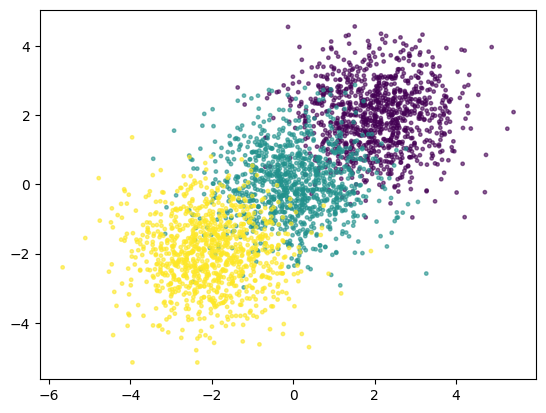

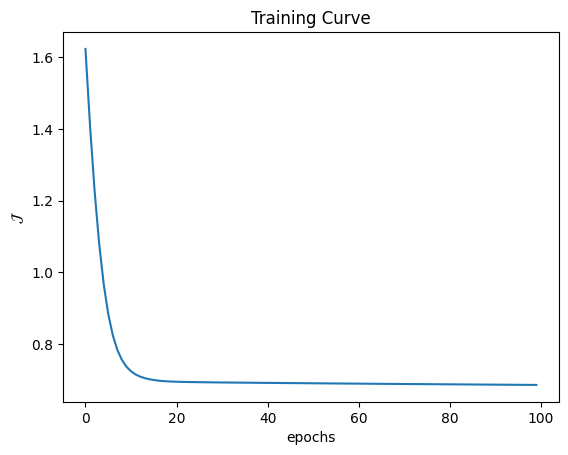

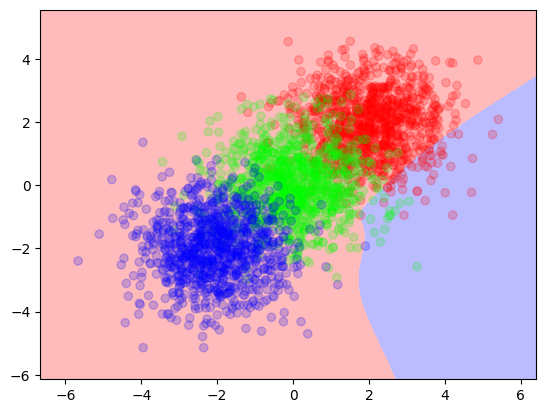

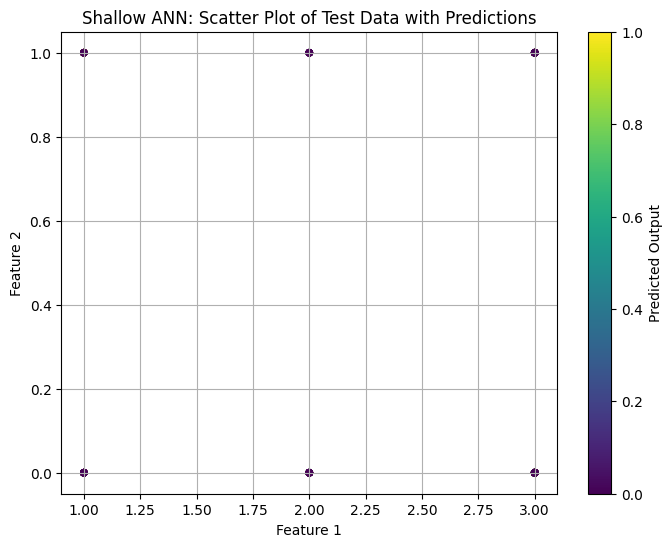

In [123]:
if __name__=="__main__":
  main_class()